# Parametrization of eccNet

## 1. Original Kernel Sizes

Dieser Abschnitt visualisiert die originale eccNet-Kernel-Parametrisierung im Vergleich zu den tatsächlichen rezeptiven Feldgrößen im Makaken-Kortex (V1/V2/V3). Ziel ist zu zeigen, dass das originale Modell kleinere rezeptive Felder simuliert, als sie in der Natur vorkommen.

In [253]:
import numpy as np
import matplotlib.pyplot as plt

In [254]:
# Eccentricity range shared by all curves in this section
ECCENTRICITY_MAX_DEG = 35
N_ECCENTRICITY_SAMPLES = 350
x = np.linspace(0, ECCENTRICITY_MAX_DEG, N_ECCENTRICITY_SAMPLES)

# eccNet layer parameters: RF size (deg) = j * eccentricity (deg) + 0.5 / n
model_params = {
    "Layer 10": (0.14, 3.75),
    "Layer 14": (0.32, 1.875),
    "Layer 18": (0.64, 0.9375),
}
model_curves = {
    label: j * x + 0.5 / n for label, (j, n) in model_params.items()
}

# Macaque RF size (deg): constant plateau up to plateau_ecc_deg, then linear growth with the given slope.
# (plateau_ecc_deg, plateau_rf_deg, slope) per visual area, e.g. V1: RF = 1 deg for ecc <= 7 deg, else ecc / 5.
MACAQUE_RF_PARAMS = {
    "V1": (7, 1, 1 / 5),
    "V2": (4, 2, 2 / 5),
    "V3": (3, 2.5, 4 / 5),
}


def macaque_rf_angle_deg(eccentricity_deg, plateau_ecc_deg, plateau_rf_deg, slope):
    return np.where(eccentricity_deg <= plateau_ecc_deg, plateau_rf_deg, slope * eccentricity_deg)


macaque_curves = {
    area: macaque_rf_angle_deg(x, plateau_ecc_deg, plateau_rf_deg, slope)
    for area, (plateau_ecc_deg, plateau_rf_deg, slope) in MACAQUE_RF_PARAMS.items()
}

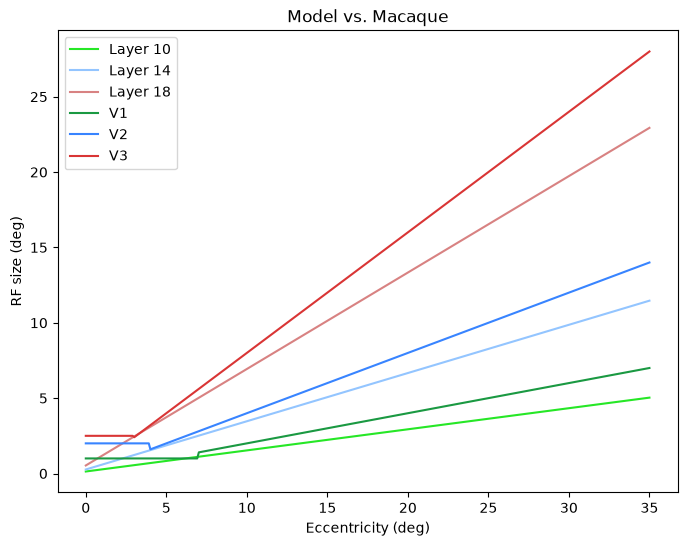

In [255]:
# Single source of truth for colors, reused by every plot in this notebook
red_shades = ["#26e726", "#93c5ff", "#d88282"]
blue_shades = ["#1a9942", "#3884ff", "#d93535"]

fig, ax = plt.subplots(figsize=(8, 6))

for color, (label, y) in zip(red_shades, model_curves.items()):
    ax.plot(x, y, color=color, label=label)

for color, (label, y) in zip(blue_shades, macaque_curves.items()):
    ax.plot(x, y, color=color, label=label)

ax.set_xlabel("Eccentricity (deg)")
ax.set_ylabel("RF size (deg)")
ax.set_title("Model vs. Macaque")
ax.legend()

plt.show()

## Physiological Correct and Parametrizable Kernel Size

Dieser Abschnitt veranschaulicht, wie sich ein konkreter Punkt mit gegebenem Abstand zum Fixationspunkt, unter Berücksichtigung von Bildschirmauflösung und Betrachtungsabstand, auf die tatsächliche (physiologisch korrekte) rezeptive Feldgröße auswirkt.

In [256]:
# Simulated display
image_width, image_height = 1920, 1080

# Point of interest and fixation point, both in pixel coordinates
x_location, y_location = 600, 300
x_fixation, y_fixation = 0, 0

# Physical display size (mm), used to derive pixel resolution
width, height = 384, 216
resolution = image_width / width  # pixel/mm

d_display = 400  # viewing distance (mm)

fovea = 2  # foveal radius (pixel), used by the eccNet radius formula

### Calculate eccentricity and receptive field angle

In [257]:
# Convert the pixel-space location/fixation points to mm on the physical display
x_location_mm = (x_location - x_fixation) / resolution
y_location_mm = (y_location - y_fixation) / resolution

# Distance between fixation and location points (mm)
distance_from_fixation_mm = np.sqrt(x_location_mm**2 + y_location_mm**2)

# Eccentricity: viewing angle between fixation and location (deg)
theta_ecc = np.degrees(np.arctan(distance_from_fixation_mm / d_display))

# Reuse the macaque RF-angle formula defined in Section 1 for the same location
theta_rf = {
    area: macaque_rf_angle_deg(theta_ecc, plateau_ecc_deg, plateau_rf_deg, slope)
    for area, (plateau_ecc_deg, plateau_rf_deg, slope) in MACAQUE_RF_PARAMS.items()
}

# Convert RF angle (deg) back to a physical radius (mm) at the location's distance from the eye
r_rf = {
    area: np.sqrt(d_display**2 + distance_from_fixation_mm**2) * np.tan(np.radians(theta))
    for area, theta in theta_rf.items()
}

print(f"distance between fixation and location points: d = {distance_from_fixation_mm} mm")
print(f"eccentricity: theta_ecc = {theta_ecc}")
print(f"receptive field size (°):")
print(f"  V1: theta_rf = {theta_rf['V1']}°")
print(f"  V2: theta_rf = {theta_rf['V2']}°")
print(f"  V3: theta_rf = {theta_rf['V3']}°")
print(f"receptive field size radius:")
print(f"  V1: r_rf = {r_rf['V1']} mm")
print(f"  V2: r_rf = {r_rf['V2']} mm")
print(f"  V3: r_rf = {r_rf['V3']} mm")

distance between fixation and location points: d = 134.16407864998737 mm
eccentricity: theta_ecc = 18.541977963997237
receptive field size (°):
  V1: theta_rf = 3.7083955927994476°
  V2: theta_rf = 7.416791185598895°
  V3: theta_rf = 14.83358237119779°
receptive field size radius:
  V1: r_rf = 27.345159530940055 mm
  V2: r_rf = 54.921036086369554 mm
  V3: r_rf = 111.73549938846314 mm


### Visualize Kernel Size as a function of location-fixation-distance

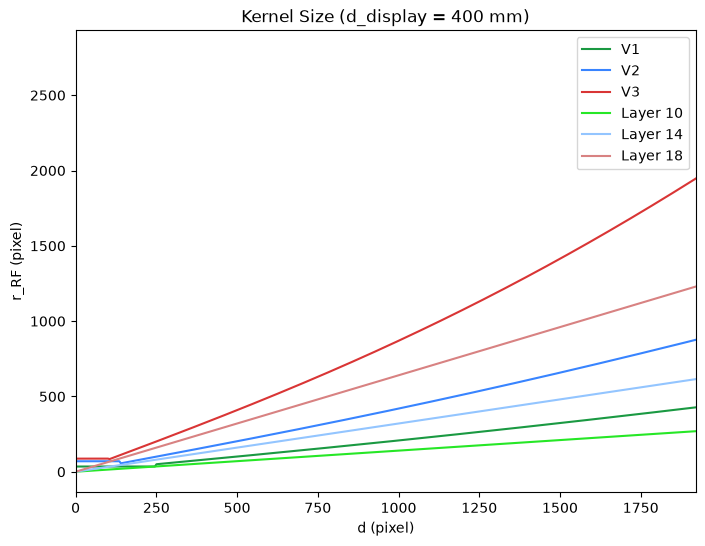

In [258]:
# Physiologically correct values, evaluated over a range of distances from fixation
D_RANGE_MAX_MM = 500
N_D_SAMPLES = 500
d_range = np.linspace(0, D_RANGE_MAX_MM, N_D_SAMPLES)  # mm
theta_ecc_range = np.degrees(np.arctan(d_range / d_display))

r_rf_range = {
    area: np.sqrt(d_display**2 + d_range**2)
    * np.tan(np.radians(macaque_rf_angle_deg(theta_ecc_range, plateau_ecc_deg, plateau_rf_deg, slope)))
    for area, (plateau_ecc_deg, plateau_rf_deg, slope) in MACAQUE_RF_PARAMS.items()
}

d_range_px = d_range * resolution
r_rf_range_px = {area: y * resolution for area, y in r_rf_range.items()}


# Original eccNet radius formula (pixel-based), distinct from the degree-based Section 1 formula
RADIUS_OFFSET_DEG = 2.5


def radius_receptive_field(d, n, j, fovea):
    return np.where(d / n < fovea, fovea, j * d - fovea + RADIUS_OFFSET_DEG)


# Reused for both the single-point (cell below) and range-based radius below
layer_r_rf_px = {
    label: radius_receptive_field(d_range_px, n, j, fovea) for label, (j, n) in model_params.items()
}

# Plot
fig, ax = plt.subplots(figsize=(8, 6))

for color, (area, y) in zip(blue_shades, r_rf_range_px.items()):
    ax.plot(d_range_px, y, color=color, label=area)

for color, (label, y) in zip(red_shades, layer_r_rf_px.items()):
    ax.plot(d_range_px, y, color=color, label=label)

ax.set_xlabel("d (pixel)")
ax.set_ylabel("r_RF (pixel)")
ax.set_xlim(0, image_width)
ax.set_title(f"Kernel Size (d_display = {d_display} mm)")
ax.legend()

plt.show()

### Vergleich am Beispielpunkt: Setup

Berechnet für den oben definierten Punkt (`x_location`, `y_location`) die rezeptiven Feldradien nach den physiologisch korrekten und den originalen eccNet-Formeln (in Pixel) und stellt die Zeichenfunktion für den grauen Hintergrund bereit. Die eigentliche Gegenüberstellung aller drei Methoden folgt am Ende des Notebooks, nach der simplifizierten Version aus Sektion 3.

In [259]:
GRAY_BACKGROUND_LEVEL = 128
image = np.full((image_height, image_width), GRAY_BACKGROUND_LEVEL, dtype=np.uint8)

# Physiologically correct RF radii at the location, converted from mm to pixel
r_rf_px = {area: r * resolution for area, r in r_rf.items()}

# Original eccNet RF radii at the location (pixel-based formula, reused from the range plot above)
d_px = distance_from_fixation_mm * resolution
layer_r_rf_px_single = {
    label: radius_receptive_field(d_px, n, j, fovea) for label, (j, n) in model_params.items()
}

# Shift location into fixation-centered coordinates (fixation point becomes the origin)
x_location_shifted = x_location - x_fixation
y_location_shifted = y_location - y_fixation

# imshow extent centered on the fixation point instead of the image center
extent = (
    -image_width / 2 - x_fixation,
    image_width / 2 - x_fixation,
    -image_height / 2 - y_fixation,
    image_height / 2 - y_fixation,
)


def draw_rf_circles(ax, radii_by_area, colors, title):
    ax.imshow(image, cmap="gray", vmin=0, vmax=255, extent=extent, origin="lower")
    # Fix the view to the image bounds *before* adding circles, so oversized circles
    # get clipped to ax.patch instead of expanding the view via autoscale
    ax.set_xlim(extent[0], extent[1])
    ax.set_ylim(extent[2], extent[3])
    ax.axhline(0, color="white", linewidth=0.8)
    ax.axvline(0, color="white", linewidth=0.8)

    # Draw largest/lowest-priority area first so it ends up at the bottom of the stack
    for color, area in zip(reversed(colors), reversed(list(radii_by_area.keys()))):
        circle = plt.Circle(
            (x_location_shifted, y_location_shifted), radii_by_area[area], color=color, alpha=0.5, label=area
        )
        ax.add_patch(circle)
        circle.set_clip_path(ax.patch)

    ax.plot(x_location_shifted, y_location_shifted, "o", color="#26e726", label="Location")
    ax.plot(0, 0, "x", color="#d93535", label="Fixation")

    ax.set_xlabel("x (pixel)")
    ax.set_ylabel("y (pixel)")
    ax.set_title(title)
    ax.legend()

## 3. Simplified but more accurate and parametrizable version

Dieser Abschnitt nähert die physiologisch korrekten rezeptiven Feldgrößen (Sektion 2) mit einer einfacheren, parametrisierbaren Formel an, statt der stückweisen Winkel-Formel aus Sektion 2.

In [260]:
# Simplified RF angle: plateau at `alpha` deg within angle_fovea_deg, else grows linearly with slope beta/5
ANGLE_FOVEA_DEG = 5


def simple_rf_angle_deg(eccentricity_deg, alpha, beta, angle_fovea_deg=ANGLE_FOVEA_DEG):
    return alpha if eccentricity_deg <= angle_fovea_deg else (beta / 5) * eccentricity_deg


def simple_radius_receptive_field(d_display, d_points, alpha, beta, eccentricity_deg, resolution, unit="px"):
    r_rf_mm = np.sqrt(d_display**2 + d_points**2) * np.tan(np.radians(simple_rf_angle_deg(eccentricity_deg, alpha, beta)))
    if unit == "mm":
        return r_rf_mm
    elif unit == "px":
        return r_rf_mm * resolution
    return None


# Simplified per-area parameters: (alpha: plateau angle in deg, beta: slope numerator)
SIMPLE_RF_PARAMS = {
    "V1": (1, 1),
    "V2": (2, 2),
    "V3": (2.5, 4),
}

layer_r_rf_px_simple = {
    area: simple_radius_receptive_field(d_display, distance_from_fixation_mm, alpha, beta, theta_ecc, resolution)
    for area, (alpha, beta) in SIMPLE_RF_PARAMS.items()
}

print(f"receptive field size radius (px, simplified):")
print(f"  V1: r_rf = {layer_r_rf_px_simple['V1']}")
print(f"  V2: r_rf = {layer_r_rf_px_simple['V2']}")
print(f"  V3: r_rf = {layer_r_rf_px_simple['V3']}")

receptive field size radius (px, simplified):
  V1: r_rf = 136.72579765470027
  V2: r_rf = 274.60518043184777
  V3: r_rf = 558.6774969423157


### Vergleich aller drei Methoden

Stellt für den Beispielpunkt alle drei Methoden nebeneinander dar: physiologisch korrekt (Sektion 2), original eccNet (Sektion 1) und die simplifizierte Version (Sektion 3).

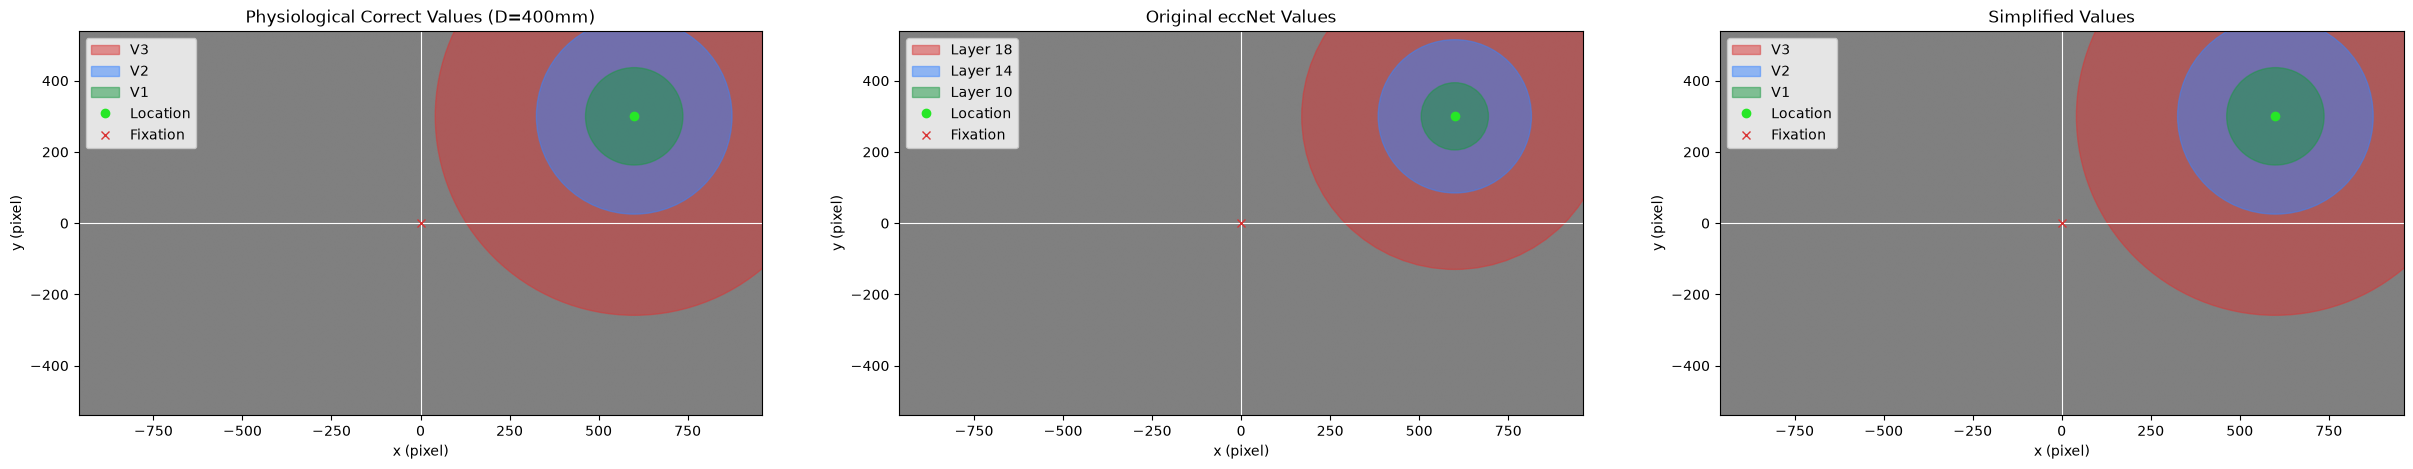

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(30, 5.6))

draw_rf_circles(axes[0], r_rf_px, blue_shades, f"Physiological Accurate Values (D={d_display}mm)")
draw_rf_circles(axes[1], layer_r_rf_px_single, blue_shades, "Original eccNet Values")
draw_rf_circles(axes[2], layer_r_rf_px_simple, blue_shades, "Simplified Values")

plt.show()

## 4. Eccentricity: eccNet-Näherung vs. geometrische Berechnung

Dieser Abschnitt vergleicht die lineare eccNet-Näherung der Exzentrizität (Layer 10) mit der exakten geometrischen Exzentrizität `arctan(d/D)` für verschiedene Betrachtungsabstände D, um zu zeigen, wie gut bzw. schlecht die lineare Näherung die tatsächliche Winkelbeziehung abbildet.

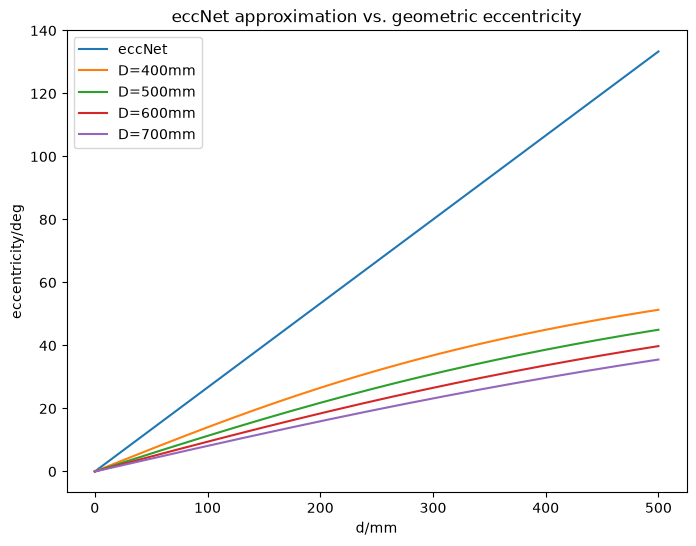

In [264]:
# eccNet Layer-10 coefficient (n from model_params), used as the linear eccentricity approximation
ECCNET_LAYER10_N = 3.75

# Viewing distances (mm) to compare against the linear approximation
VIEWING_DISTANCES_MM = (400, 500, 600, 700)

fig, ax = plt.subplots(figsize=(8, 6))

# Linear eccNet approximation: eccentricity (deg) = d / n
ax.plot(d_range, d_range / ECCNET_LAYER10_N, label="eccNet")

# Exact geometric eccentricity for each viewing distance D
for D in VIEWING_DISTANCES_MM:
    ax.plot(d_range, np.degrees(np.arctan(d_range / D)), label=f"D={D}mm")

ax.set_xlabel("d/mm")
ax.set_ylabel("eccentricity/deg")
ax.set_title("eccNet approximation vs. geometric eccentricity")
ax.legend()

plt.show()